
Attaching package: 'lubridate'


The following objects are masked from 'package:base':

    date, intersect, setdiff, union


New names:
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...11`
• `` -> `...12`
• `` -> `...13`



2023-01-31 2023-02-28 2023-03-31 2023-04-28 2023-05-31 2023-06-30 2023-07-31 
       500        500        500        500        500        500        500 
2023-08-31 2023-09-30 2023-10-31 2023-11-30 2023-12-31 2024-01-31 2024-02-29 
       500        500        500        500        500        500        500 
2024-03-31 2024-04-30 2024-05-31 2024-06-30 2024-07-31 2024-08-31 2024-09-30 
       500        500        500        500        500        500        500 
2024-10-31 2024-11-30 2024-12-31 2025-01-31 2025-02-28 2025-03-31 2025-04-30 
       500        500        500        500        500        500        500 
2025-05-31 2025-06-30 2025-07-31 
       500        500        500 

Picking joint bandwidth of 16.5



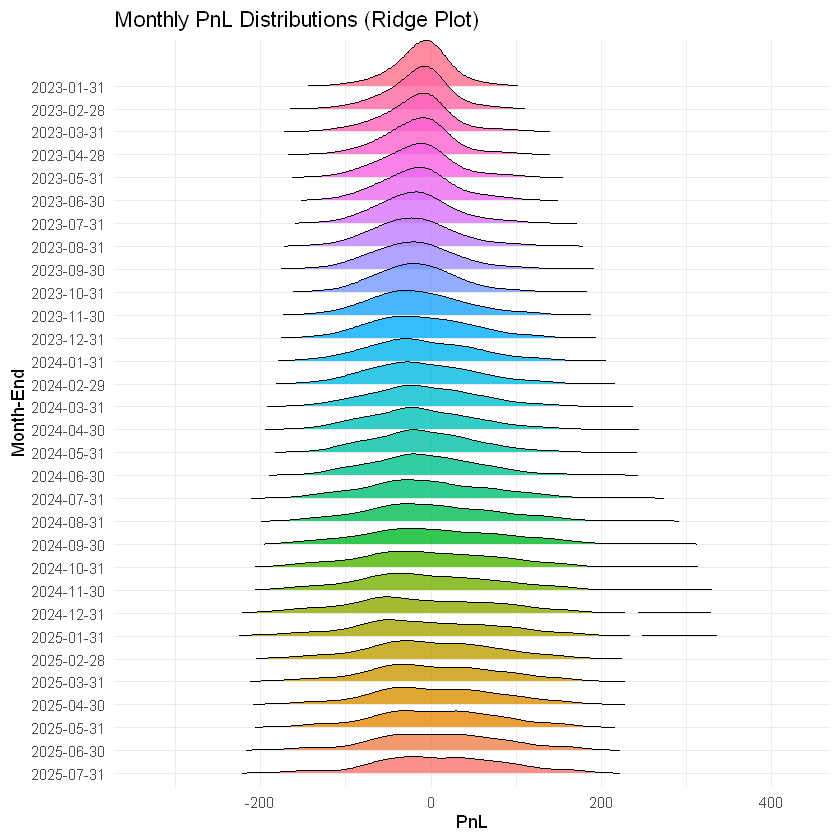

In [14]:
library(readxl)
library(ggridges)
library(ggplot2)
library(lubridate)    # For easy date handling

# Read data
df <- read_excel("Month-End_PnL_Distributions for Ridge Plot.xlsx")
names(df) <- trimws(names(df))

# If Month-End is a Date, convert to Year-Month label
if (inherits(df$`Month-End`, "Date")) {
  df$MonthLabel <- format(df$`Month-End`, "%b %Y")   # e.g. "Jul 2025"
} else {
  df$MonthLabel <- as.character(df$`Month-End`)
}

# View to check correctness
table(df$MonthLabel)  # Each month should have about 500

# Set order of factors
df$MonthLabel <- factor(df$MonthLabel, levels = unique(df$MonthLabel))

# Ridge plot with exactly one hump per month
ggplot(df, aes(x = `PnL Distribution`, y = MonthLabel, fill = MonthLabel)) +
  geom_density_ridges(scale = 2, alpha = 0.8, rel_min_height = 0.01, show.legend = FALSE) +
  labs(
    title = "Monthly PnL Distributions (Ridge Plot)",
    x = "PnL",
    y = "Month-End"
  ) +
  theme_minimal()


New names:
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...11`
• `` -> `...12`
• `` -> `...13`
Warning message in geom_density_ridges_gradient(scale = 5, rel_min_height = 0.01, :
"Ignoring unknown parameters: `size`"
Warning message:
"`stat(x)` was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(x)` instead."
Picking joint bandwidth of 16.5



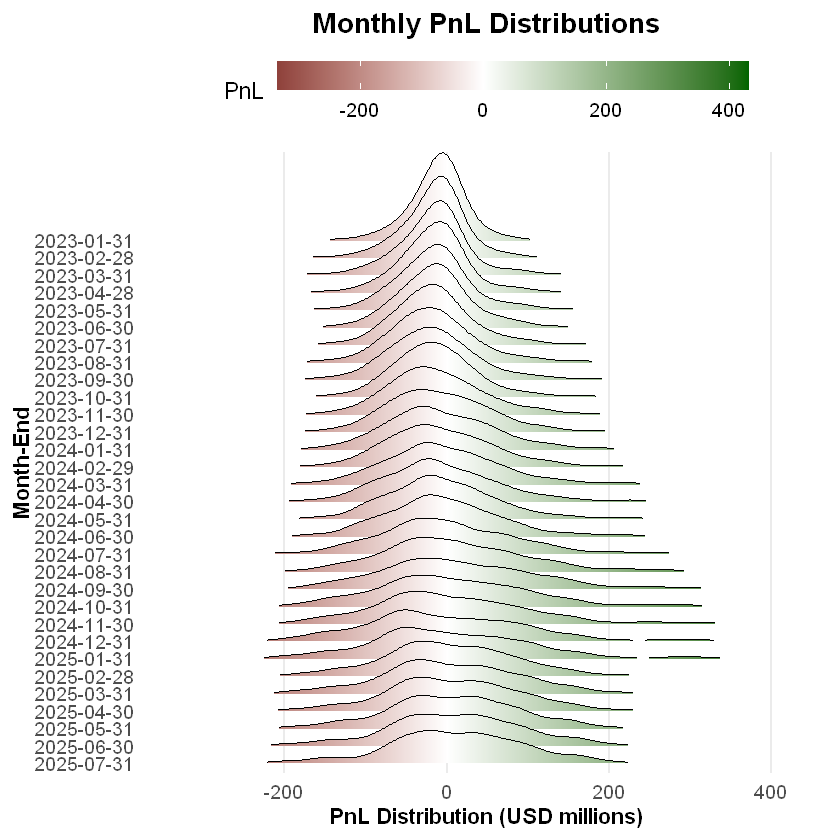

In [13]:
library(readxl)
library(ggridges)
library(ggplot2)

# Load and clean data
df <- read_excel("Month-End_PnL_Distributions for Ridge Plot.xlsx")
names(df) <- trimws(names(df))  # Clean column names

# Generate nice month labels
if (inherits(df$`Month-End`, "Date")) {
  df$MonthLabel <- format(df$`Month-End`, "%b %Y")
} else {
  df$MonthLabel <- as.character(df$`Month-End`)
}
df$MonthLabel <- factor(df$MonthLabel, levels = rev(sort(unique(df$MonthLabel))))

p <- ggplot(df, aes(x = `PnL Distribution`, y = MonthLabel, fill = stat(x))) +
  geom_density_ridges_gradient(
    scale = 5,         # Increase this! Taller humps and more overlap
    rel_min_height = 0.01,
    alpha = 0.85,
    color = "black",
    size = 0.3
  ) +
  scale_fill_gradient2(
    low = "#67000d",
    mid = "white",
    high = "#006400",
    midpoint = 0,
    name = "PnL"
  ) +
  labs(
    title = "Monthly PnL Distributions",
    x = "PnL Distribution (USD millions)",
    y = "Month-End"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "top",
    legend.key.width = unit(2, "cm"),
    axis.title.y = element_text(size = 13, face = "bold"),
    axis.title.x = element_text(size = 13, face = "bold"),
    plot.title = element_text(hjust = 0.5, size = 17, face = "bold"),
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank()
  )
print(p)



# Cornish-Fisher Expansion

In [6]:
# Only run this ONCE as needed, not each time you run your script
# install.packages("moments")

library(readr)
library(dplyr)
library(moments)     # for skewness and kurtosis
library(openxlsx)    # for Excel export

# Cornish-Fisher VaR function
cornish_fisher_var <- function(pnl_series, alpha = 0.01) {
  mean_val <- mean(pnl_series)
  std_val <- sd(pnl_series)
  s <- skewness(pnl_series)
  k <- kurtosis(pnl_series) - 3  # moments::kurtosis gives excess by default
  z <- qnorm(alpha)
  z_cf <- z +
    (z^2 - 1) * s / 6 +
    (z^3 - 3*z) * k / 24 -
    (2 * z^3 - 5 * z) * s^2 / 36
  var_cf <- -(mean_val + z_cf * std_val)
  return(var_cf)
}

# Historical VaR
historical_var <- function(pnl_series, alpha = 0.01) {
  return(-quantile(pnl_series, alpha, type = 7))
}

# 99.99% VaR by scaling 99% under normality
scale_var_9999_normal <- function(var99) {
  z_99 <- abs(qnorm(0.01))
  z_9999 <- abs(qnorm(0.0001))
  scale_factor <- z_9999 / z_99
  return(var99 * scale_factor)
}

# Read your file
df <- read_csv("CF.csv") %>%
  mutate(date = as.Date(date, format = "%m/%d/%Y"))  # <-- parse date in MM/DD/YYYY

# Calculate VaR metrics by date
result <- df %>%
  group_by(date) %>%
  summarise(
    VaR = round(historical_var(PnL, 0.01) / 1e6),
    CFVAR99 = round(cornish_fisher_var(PnL, 0.01) / 1e6),
    VaR9999_normal_scaled = round(scale_var_9999_normal(historical_var(PnL, 0.01)) / 1e6),
    CFVAR9999 = round(cornish_fisher_var(PnL, 0.0001) / 1e6)
  ) %>%
  arrange(desc(date))  # dates are now Date type, sorted descending

# Place 2025-07-31 on top, others descending
special_row <- filter(result, date == as.Date('2025-07-31'))
remaining <- filter(result, date != as.Date('2025-07-31'))
final_result <- bind_rows(special_row, remaining)

# Print the result
print(final_result)

# Export to Excel
write.xlsx(final_result, "VaR_results_R.xlsx", row.names = FALSE)


Rows: 15500 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): date
dbl (1): PnL

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# A tibble: 31 × 5
   date         VaR CFVAR99 VaR9999_normal_scaled CFVAR9999
   <date>     <dbl>   <dbl>                 <dbl>     <dbl>
 1 2025-07-31   189     179                   303       298
 2 2025-06-30   187     176                   300       282
 3 2025-05-31   177     168                   283       257
 4 2025-04-30   164     167                   262       249
 5 2025-03-31   187     178                   298       267
 6 2025-02-28   178     173                   284       262
 7 2025-01-31   198     191                   316       322
 8 2024-12-31   196     204                   314       335
 9 2024-11-30   180     186                   288       308
10 2024-10-31   176     187                   281       303
# ℹ 21 more rows


Warning message:
"Please use 'rowNames' instead of 'row.names'"
